In [1]:
import pandas as pd
from cartopy import crs as ccrs
import xarray as xr
from xhistogram.xarray import histogram
import numpy as np
# import gfdl_utils as gu
import glob
import re
from scipy.interpolate import griddata
import geopy
import cmocean.cm as cmo
import cmocean
import gsw
from geopy import distance
import xesmf as xe
# import sectionate
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook")
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
import warnings
import gsw
import cartopy.feature as cfeature

In [2]:
# GLODAP:model variable naming conventions
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'},
    'cfc11':{'conversion':1e12/1035,'cmap':cmo.matter_r,'units':r'pmol kg$^{-1}$'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK'},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'ct':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C'},
    'sa':{'conversion':1,'cmap':cmocean.cm.haline,'units':r'g kg$^{-1}$'},
    'so':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu'}, 
    'density':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},
    'rho2':{'conversion':1,'cmap':cmocean.cm.dense,'units':r'kg m$^{-3}$'},

    'agessc':{'conversion':1,'cmap':cmocean.cm.speed,'units':'years'}
}

In [3]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/" + x
ds_bottom = xr.open_dataset(datadir("global_bottom_tracers_sigma2.nc")).groupby("time.year").mean("time")

In [4]:
def get_trend(ds, dim = "year"): 
    # We can fit a polynomial of degree 1 to the monthly anomalies 
    p = ds.polyfit(dim=dim, deg=1)
    
    # Now, apply that polynomial to get the fitted values from the data
    trend = p.polyfit_coefficients.sel(degree = 1)
    trend["geolat"] = ds["geolat"]
    trend["geolon"] = ds["geolon"]

    return trend


In [5]:
trend_over_period = lambda ds, time_slice: get_trend(ds.sel(year = time_slice), dim = "year")
average_period = lambda ds, time_slice: ds.sel(year = time_slice).mean("year", skipna = True) 

def plot_spatial(a, avg_var, vmin=None, vmax=None, extend = "both", cmap = "bwr"):

        if vmin is None or vmax is None:
            warnings.warn(
                "One or more of vmin, vmax, or levels was not provided. "
                "Automatically calculating all three from the data range."
            )
            vmin = float(avg_var.min())
            vmax = float(avg_var.max())
            n_levels = 21
            levels = np.linspace(vmin, vmax, n_levels)
            levels = np.round(levels, decimals = 2)
        
        cb = a.pcolormesh(avg_var["geolon"], avg_var["geolat"], avg_var.values, 
                                          vmin = vmin, vmax = vmax, 
                                          cmap = cmap,  transform = ccrs.PlateCarree())
        return cb

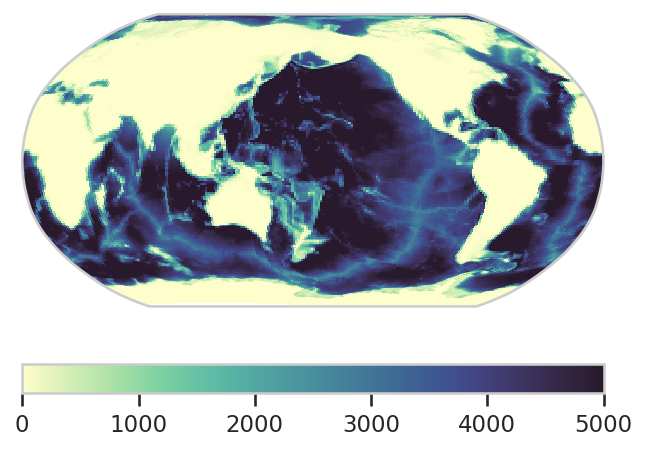

In [6]:
fig, ax = plt.subplots(1, 1, figsize = (5, 5), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})
cb = ax.pcolormesh(ds_bottom["geolon"], ds_bottom["geolat"], ds_bottom.deptho.values, 
                                  vmin = 0, vmax = 5000, 
                                  cmap = cmo.deep,  transform = ccrs.PlateCarree())
fig.colorbar(cb, orientation = "horizontal", fraction= 0.1, pad = 0.1)

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/lib/python3.12/site-packages/xarray/core/nputils.py:222: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/lib/python3.12/site-packages/xarray/core/nputils.py:222: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/lib/python3.12/site-packages/xarray/core/nputils.py:222: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


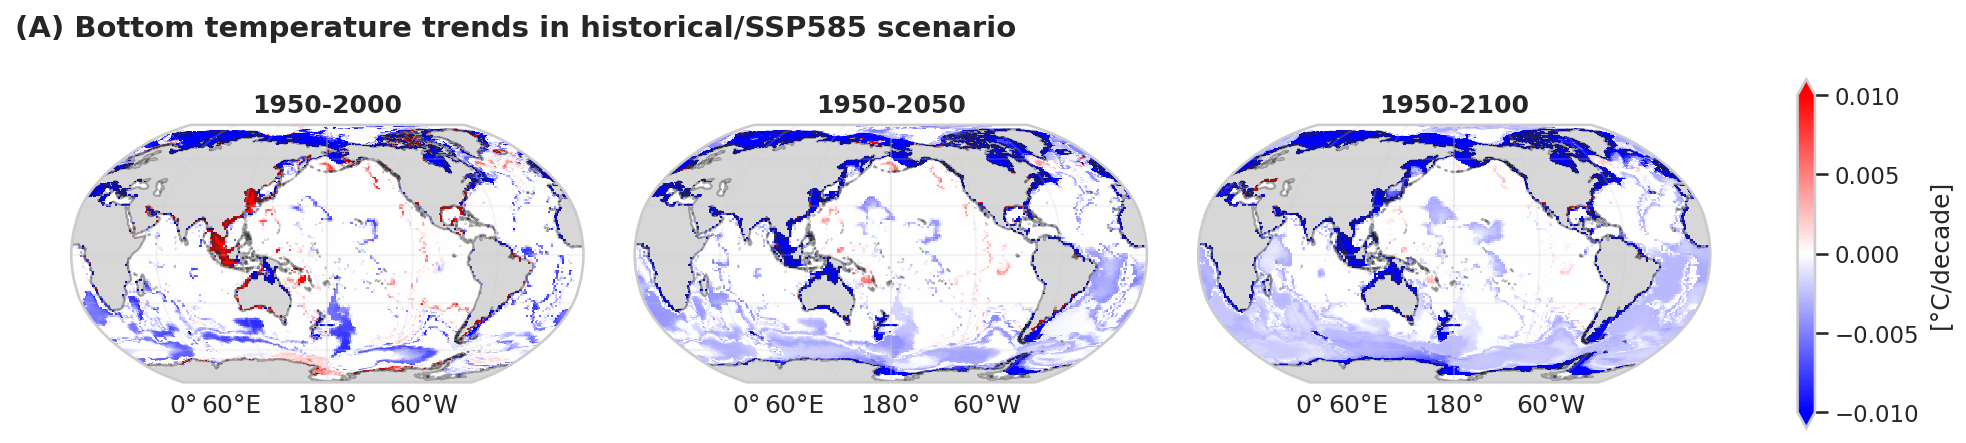

In [7]:
time_slices = [("1950", "2000"), ("1950", "2050"),  ("1950", "2100")]
expts = ["control", "forced"]
variable = "rho2"; variable_name = "Conservative Temperature"; 
vmin = -0.01; vmax = 0.01; 
extend = "both"

fig, ax = plt.subplots(1, 3, figsize = (15, 10), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})

for (j, a) in enumerate(ax):
    cmap = "bwr"
    t0, t1 = time_slices[j]

    ct_effective_trend = trend_over_period(ds_bottom[variable], slice(t0, t1))
    ct_effective_trend = ct_effective_trend.sel(exp = "forced")

    conversion = 10 #Celsius / year -> Celsius / decade
    
    ct_effective_trend = conversion * ct_effective_trend
    
    cb = a.pcolormesh(ct_effective_trend["geolon"], ct_effective_trend["geolat"], ct_effective_trend.values, 
                                      vmin = vmin, vmax = vmax, 
                                      cmap = cmap,  transform = ccrs.PlateCarree())

    # a.contour(ct_effective_trend["geolon"], ct_effective_trend["geolat"], ct_effective_trend.values, 
    #                                   levels = [0.005],  transform = ccrs.PlateCarree())
    
    a.set_title(f"\n{t0}-{t1}", fontweight = "bold")

for a in ax: 
    a.coastlines(resolution = "50m", alpha = 0.2)
    a.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="#3A3B3C", alpha = 0.2))
    gl = a.gridlines(draw_labels = True, alpha = 0.2); 
    gl.top_labels = False; 
    if j > 0: 
        gl.left_labels = False; 
        
fig.subplots_adjust(wspace = 0.1)
fig.colorbar(cb, ax = ax, orientation = "vertical", fraction = 0.01, pad = 0.05, extend = "both",
            label = "[°C/decade]")
fig.text(0.1, 0.64, '(A) Bottom temperature trends in historical/SSP585 scenario',  
         ha='left', fontsize=14, fontweight='bold')
fig.savefig("plots/bottom_dens_trend_in_forced.png", dpi = 250, bbox_inches = "tight")

Text(0.1, 0.64, '(A) Bottom temperature trends in historical/SSP585 scenario')

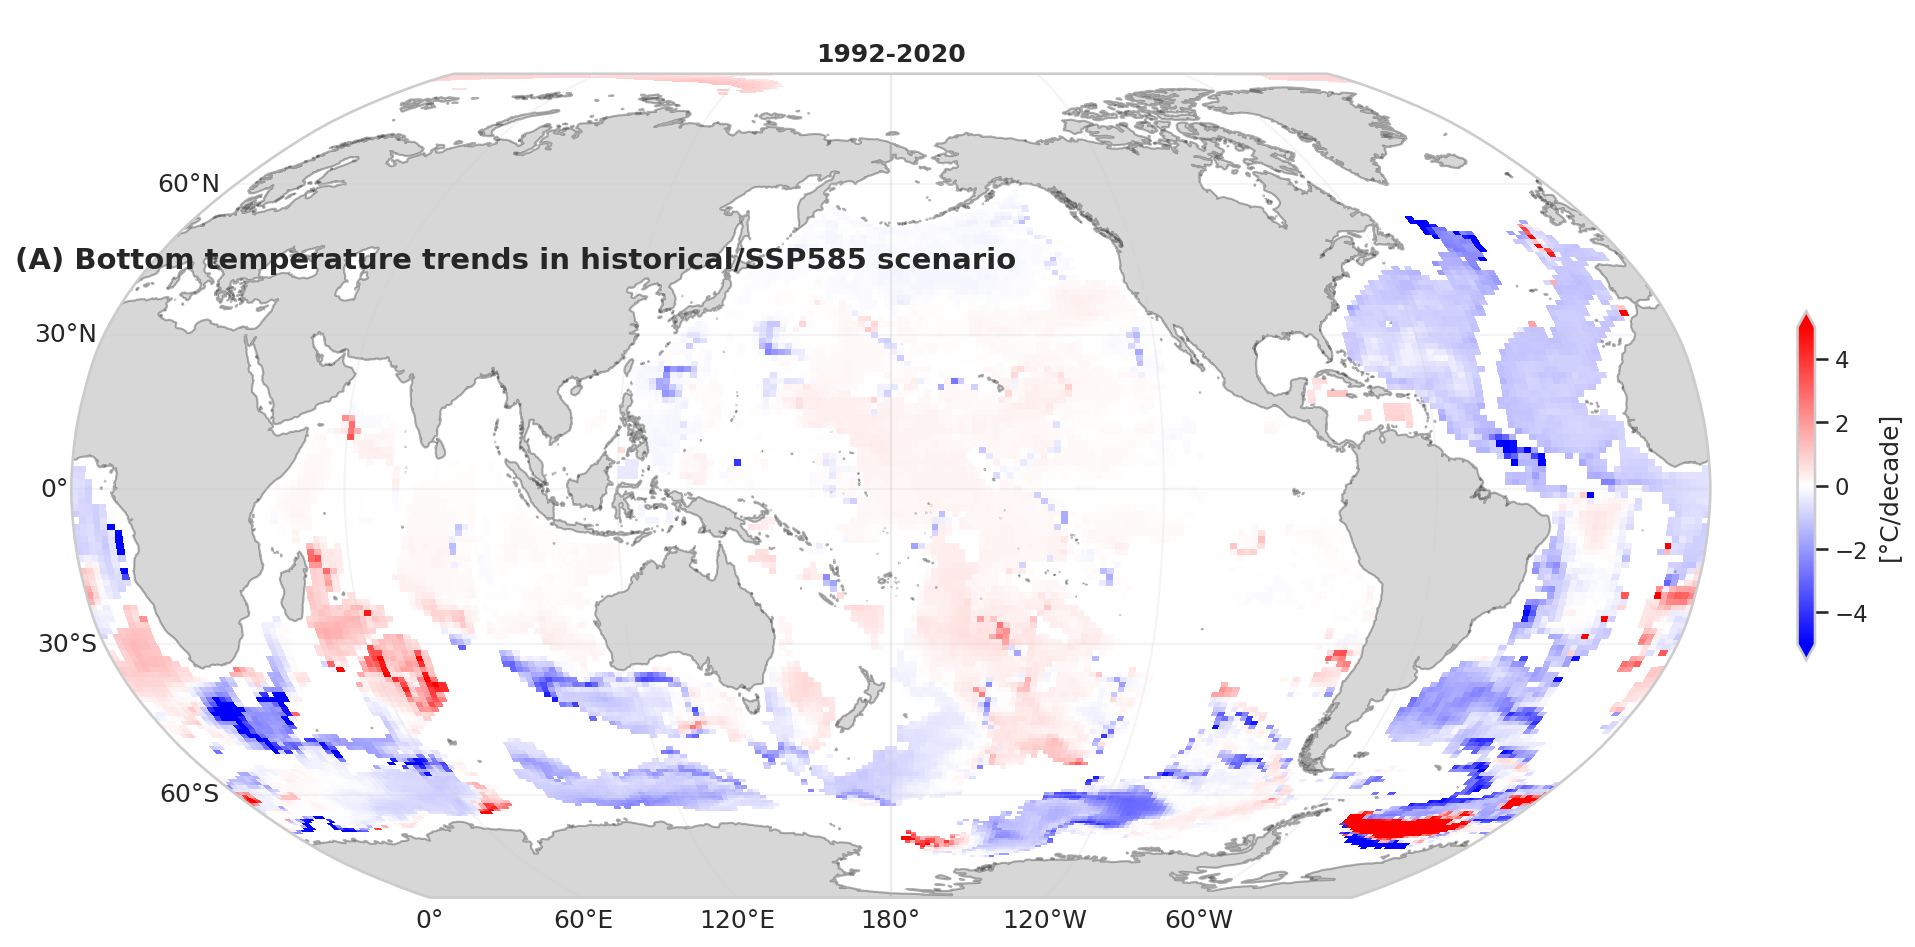

In [8]:
time_slices = [("1992", "2020")]
expts = ["control", "forced"]
variable = "ct"; variable_name = "Conservative Temperature"; 
vmin = -5; vmax = 5; 
extend = "both"

fig, ax = plt.subplots(1, 1, figsize = (15, 10), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})
ax = [ax]
for (j, a) in enumerate(ax):
    cmap = "bwr"
    t0, t1 = time_slices[j]

    ct_effective_trend = trend_over_period(ds_bottom[variable], slice(t0, t1))
    ct_effective_trend = ct_effective_trend.sel(exp = "control")

    conversion = 1000 #Celsius / year -> Celsius / decade
    
    ct_effective_trend = conversion * ct_effective_trend.where(ct_effective_trend.deptho > 4000)
    
    cb = a.pcolormesh(ct_effective_trend["geolon"], ct_effective_trend["geolat"], ct_effective_trend.values, 
                                      vmin = vmin, vmax = vmax, 
                                      cmap = cmap,  transform = ccrs.PlateCarree())
    
    a.set_title(f"\n{t0}-{t1}", fontweight = "bold")

for a in ax: 
    a.coastlines(resolution = "50m", alpha = 0.2)
    a.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="#3A3B3C", alpha = 0.2))
    gl = a.gridlines(draw_labels = True, alpha = 0.2); 
    gl.top_labels = False; 
    if j > 0: 
        gl.left_labels = False; 
        
fig.subplots_adjust(wspace = 0.1)
fig.colorbar(cb, ax = ax, orientation = "vertical", fraction = 0.01, pad = 0.05, extend = "both",
            label = "[°C/decade]")
fig.text(0.1, 0.64, '(A) Bottom temperature trends in historical/SSP585 scenario',  
         ha='left', fontsize=14, fontweight='bold')

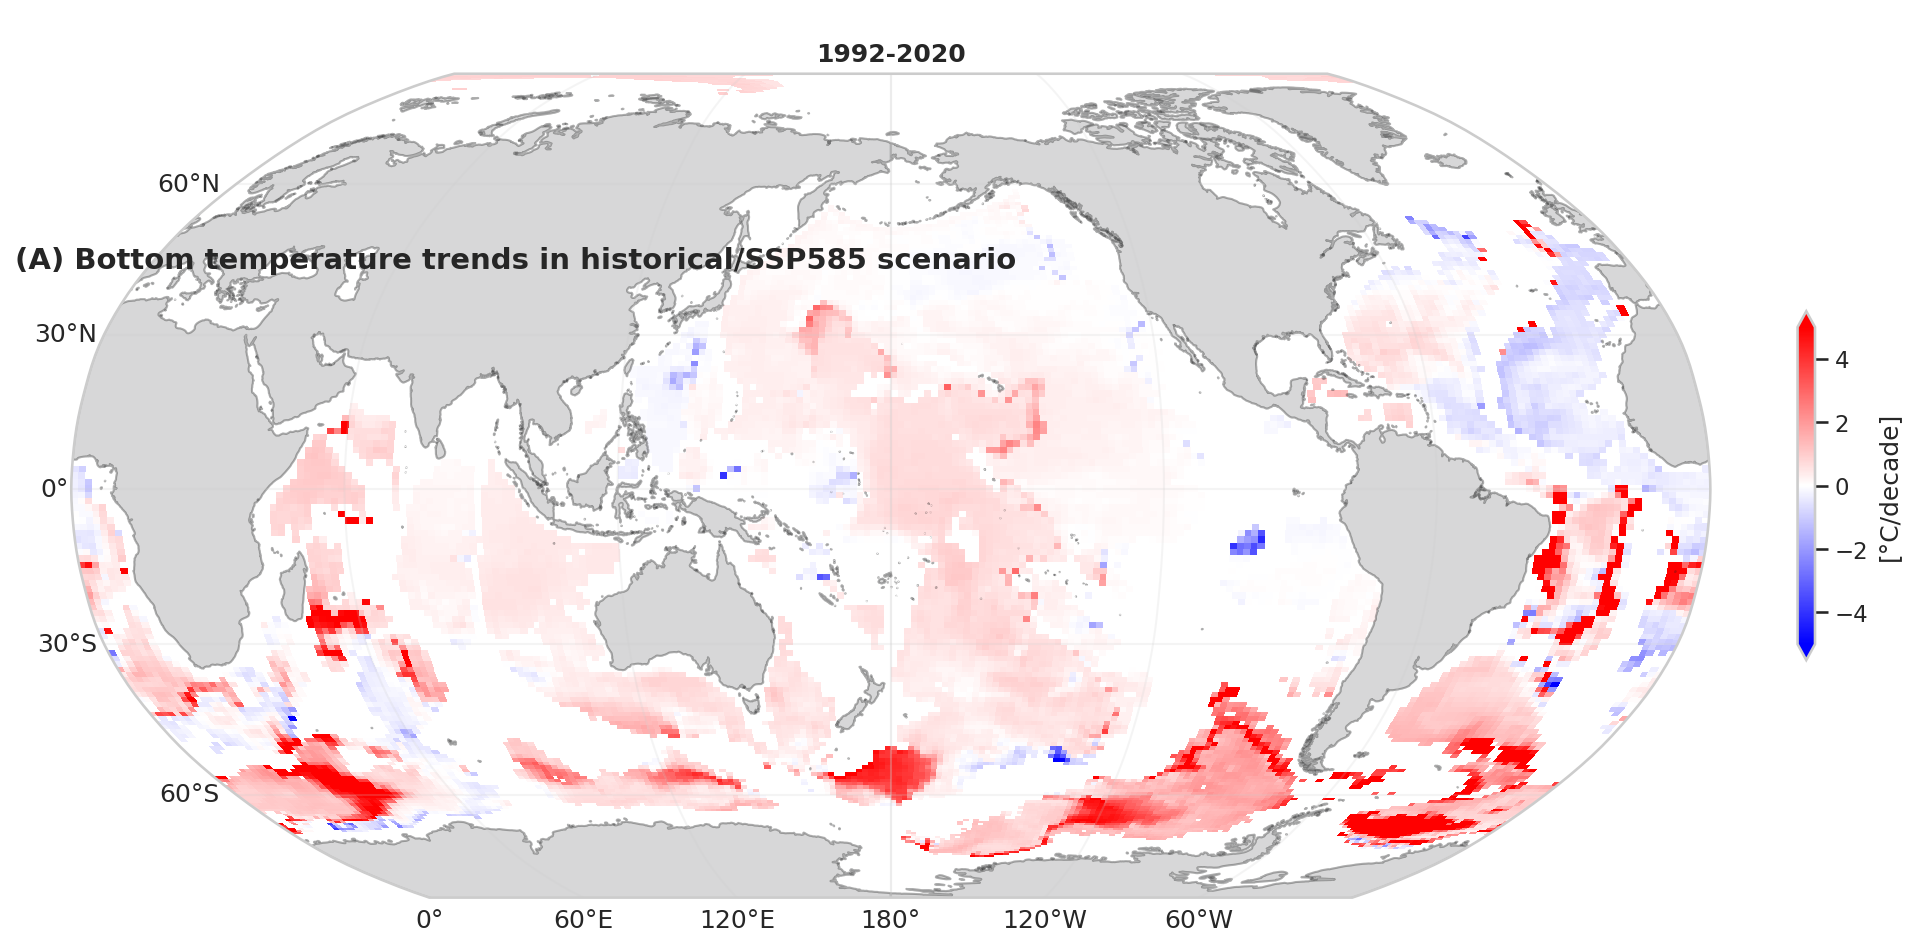

In [9]:
time_slices = [("1992", "2020")]
expts = ["control", "forced"]
variable = "ct"; variable_name = "Conservative Temperature"; 
vmin = -5; vmax = 5; 
extend = "both"

fig, ax = plt.subplots(1, 1, figsize = (15, 10), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})
ax = [ax]
for (j, a) in enumerate(ax):
    cmap = "bwr"
    t0, t1 = time_slices[j]

    ct_effective_trend = trend_over_period(ds_bottom[variable], slice(t0, t1))
    ct_effective_trend = ct_effective_trend.sel(exp = "forced")

    conversion = 1000 #Celsius / year -> Celsius / decade
    
    ct_effective_trend = conversion * ct_effective_trend.where(ct_effective_trend.deptho > 4000)
    
    cb = a.pcolormesh(ct_effective_trend["geolon"], ct_effective_trend["geolat"], ct_effective_trend.values, 
                                      vmin = vmin, vmax = vmax, 
                                      cmap = cmap,  transform = ccrs.PlateCarree())

    # a.contour(ct_effective_trend["geolon"], ct_effective_trend["geolat"], ct_effective_trend.values, 
    #                                   levels = [0.005],  transform = ccrs.PlateCarree())
    
    a.set_title(f"\n{t0}-{t1}", fontweight = "bold")

for a in ax: 
    a.coastlines(resolution = "50m", alpha = 0.2)
    a.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="#3A3B3C", alpha = 0.2))
    gl = a.gridlines(draw_labels = True, alpha = 0.2); 
    gl.top_labels = False; 
    if j > 0: 
        gl.left_labels = False; 
        
fig.subplots_adjust(wspace = 0.1)
fig.colorbar(cb, ax = ax, orientation = "vertical", fraction = 0.01, pad = 0.05, extend = "both",
            label = "[°C/decade]")
fig.text(0.1, 0.64, '(A) Bottom temperature trends in historical/SSP585 scenario',  
         ha='left', fontsize=14, fontweight='bold')
fig.savefig("plots/bottom_temp_trend_in_forced_1992_2017.png", dpi = 250, bbox_inches = "tight")

In [10]:
ds_bottom_effect = ds_bottom.sel(exp = "forced") - ds_bottom.sel(exp = "control")
ds_bottom_effect = ds_bottom_effect.assign_coords(exp=["effect"])

In [11]:
ds_bottoms = xr.concat([ds_bottom, ds_bottom_effect], dim = "exp")

In [ ]:
time_slices = [("1992", "2020"), ("1992", "2050"),  ("1992", "2100")]

# Example setup
experiments = ["forced", "control", "effect"]
labels = ["(A) Bottom temperature trends in historical/SSP585 scenario", 
          "(B) Bottom temperature trends in control scenario",
          "(C) Bottom temperature trends due to historical/SSP585 forcing"]

n_exp = len(experiments)
n_slices = len(time_slices)
conversion = 10  # °C/year → °C/decade
cmap = "bwr"
variable = "ct"; variable_name = "Conservative Temperature"; 
vmin = -0.07; vmax = 0.07; 

fig, ax = plt.subplots(
    nrows=n_exp, ncols=n_slices,
    figsize=(22, 13),
    subplot_kw={'projection': ccrs.Robinson(central_longitude=120)},
)

# ensure ax is always 2D
ax = np.atleast_2d(ax)

for i, exp in enumerate(experiments):
    for j, (t0, t1) in enumerate(time_slices):
        a = ax[i, j]

        # --- compute trend for this exp and time slice ---
        ct_effective_trend = trend_over_period(
            ds_bottoms.sel(exp=exp)[variable], slice(t0, t1)
        )
        ct_effective_trend = conversion * ct_effective_trend.where(ct_effective_trend.deptho > 4000)

        # --- plot ---
        cb = a.pcolormesh(ct_effective_trend["geolon"], ct_effective_trend["geolat"],
            ct_effective_trend.values,
            vmin=vmin, vmax=vmax,
            cmap=cmap, transform=ccrs.PlateCarree())

        # title for each column
        a.set_title(f"{t0}–{t1}", fontsize=12)

        # coastlines + land mask
        a.coastlines(resolution="50m", alpha=0.2)
        a.add_feature(cfeature.NaturalEarthFeature( 'physical', 'land', '50m', edgecolor='face', facecolor="k", alpha=0.9))

        # gridlines
        gl = a.gridlines(draw_labels=True, alpha=0.1, zorder = 0)
        gl.top_labels = False
        if j > 0:
            gl.left_labels = False

    # --- label each row with experiment name ---
    ax[i, 0].text(
        0.0, 1.15, labels[i],
        va="bottom", ha="left",
        fontsize=14, fontweight="bold",
        transform=ax[i, 0].transAxes
    )

# --- colorbar + layout ---
fig.subplots_adjust(wspace=0.1, hspace=0.35)
fig.colorbar(cb, ax=ax, orientation="vertical", fraction=0.012, pad=0.05, 
             extend="both", label="[°C/decade]")
fig.savefig("plots/bottom_temp_trends.png", dpi = 300, bbox_inches = "tight")

In [ ]:
time_slices = [("1992", "2020"), ("1992", "2050"),  ("1992", "2100")]

# Example setup
experiments = ["forced", "control", "effect"]
labels = ["(A) Bottom salinity trends in historical/SSP585 scenario", 
          "(B) Bottom salinity trends in control scenario",
          "(C) Bottom salinity trends due to historical/SSP585 forcing"]

n_exp = len(experiments)
n_slices = len(time_slices)
conversion = 10  # °C/year → °C/decade
cmap = "bwr"
variable = "sa"; variable_name = "Absolute Salinity"; 
vmin = -0.005; vmax = 0.005; 

fig, ax = plt.subplots(
    nrows=n_exp, ncols=n_slices,
    figsize=(22, 13),
    subplot_kw={'projection': ccrs.Robinson(central_longitude=120)},
)

# ensure ax is always 2D
ax = np.atleast_2d(ax)

for i, exp in enumerate(experiments):
    for j, (t0, t1) in enumerate(time_slices):
        a = ax[i, j]

        # --- compute trend for this exp and time slice ---
        ct_effective_trend = trend_over_period(
            ds_bottoms.sel(exp=exp)[variable], slice(t0, t1)
        )
        ct_effective_trend = conversion * ct_effective_trend.where(ct_effective_trend.deptho > 4000)

        # --- plot ---
        cb = a.pcolormesh(ct_effective_trend["geolon"], ct_effective_trend["geolat"],
            ct_effective_trend.values,
            vmin=vmin, vmax=vmax,
            cmap=cmap, transform=ccrs.PlateCarree())

        # title for each column
        a.set_title(f"{t0}–{t1}", fontsize=12)

        # coastlines + land mask
        a.coastlines(resolution="50m", alpha=0.2)
        a.add_feature(cfeature.NaturalEarthFeature( 'physical', 'land', '50m', edgecolor='face', facecolor="k", alpha=0.9))

        # gridlines
        gl = a.gridlines(draw_labels=True, alpha=0.1, zorder = 0)
        gl.top_labels = False
        if j > 0:
            gl.left_labels = False

    # --- label each row with experiment name ---
    ax[i, 0].text(
        0.0, 1.15, labels[i],
        va="bottom", ha="left",
        fontsize=14, fontweight="bold",
        transform=ax[i, 0].transAxes
    )

# --- colorbar + layout ---
fig.subplots_adjust(wspace=0.1, hspace=0.35)
fig.colorbar(cb, ax=ax, orientation="vertical", fraction=0.012, pad=0.05, 
             extend="both", label="[PSU/decade]")
fig.savefig("plots/bottom_sal_trends.png", dpi = 300, bbox_inches = "tight")

Text(0.1, 0.64, 'Age anomaly in historical/SSP585 scenario')

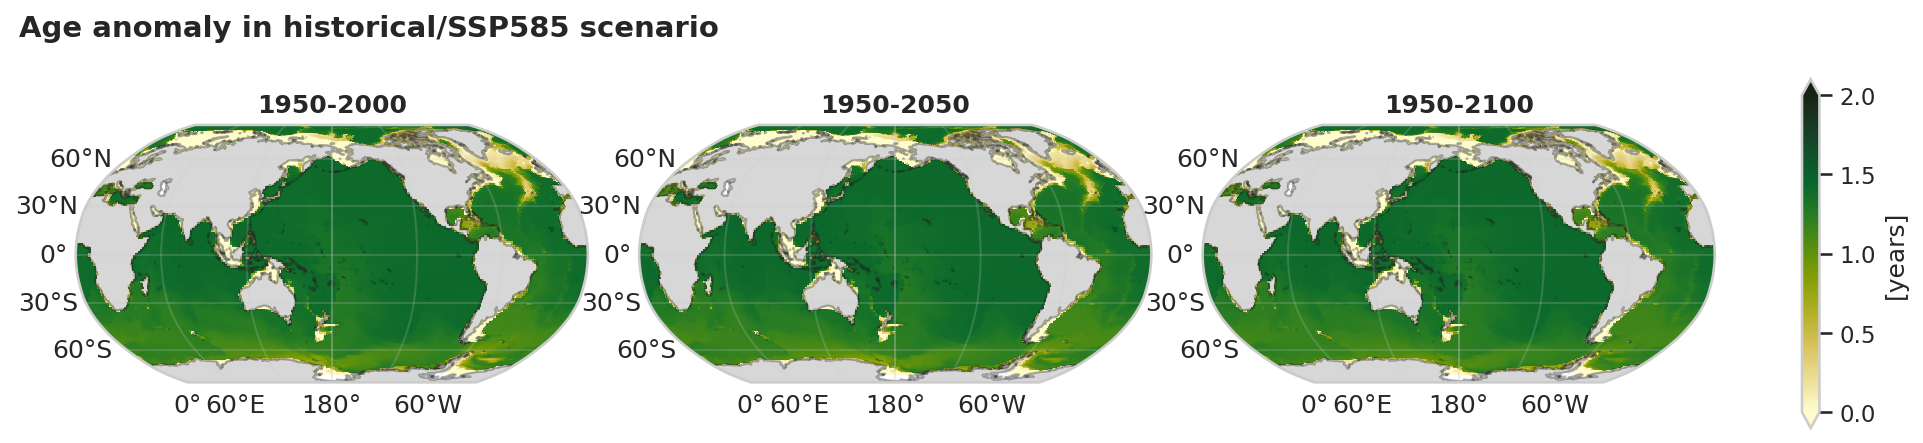

In [14]:
time_slices = [("1950", "2000"), ("1950", "2050"),  ("1950", "2100")]
expts = ["control", "forced"]
variable = "agessc";
vmin = 0; vmax = 2.; 
extend = "both"
cmap = "bwr"
fig, ax = plt.subplots(1, 3, figsize = (15, 10), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})

for (j, a) in enumerate(ax):
    cmap = "bwr"
    t0, t1 = time_slices[j]

    avg_age = average_period(ds_bottom[variable], slice(t0, t1))
        
    avg_age = avg_age.sel(exp = "forced") / avg_age.sel(exp = "forced").mean()
    
    cb = plot_spatial(a, avg_age, vmin, vmax, extend, cmap = cmo.speed)
    a.set_title(f"\n{t0}-{t1}", fontweight = "bold")

for a in ax: 
    a.coastlines(resolution = "50m", alpha = 0.2)
    a.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="#3A3B3C", alpha = 0.2))
    gl = a.gridlines(draw_labels = True, alpha = 0.2); 
    gl.top_labels = False; 

fig.subplots_adjust(wspace = 0.1)
fig.colorbar(cb, ax = ax, orientation = "vertical", fraction = 0.01, pad = 0.05, extend = "both",
            label = "[years]")
fig.text(0.1, 0.64, 'Age anomaly in historical/SSP585 scenario', 
         ha='left', fontsize=14, fontweight='bold')

Text(0.1, 0.64, 'Bottom cell thickness in historical/SSP585 scenario')

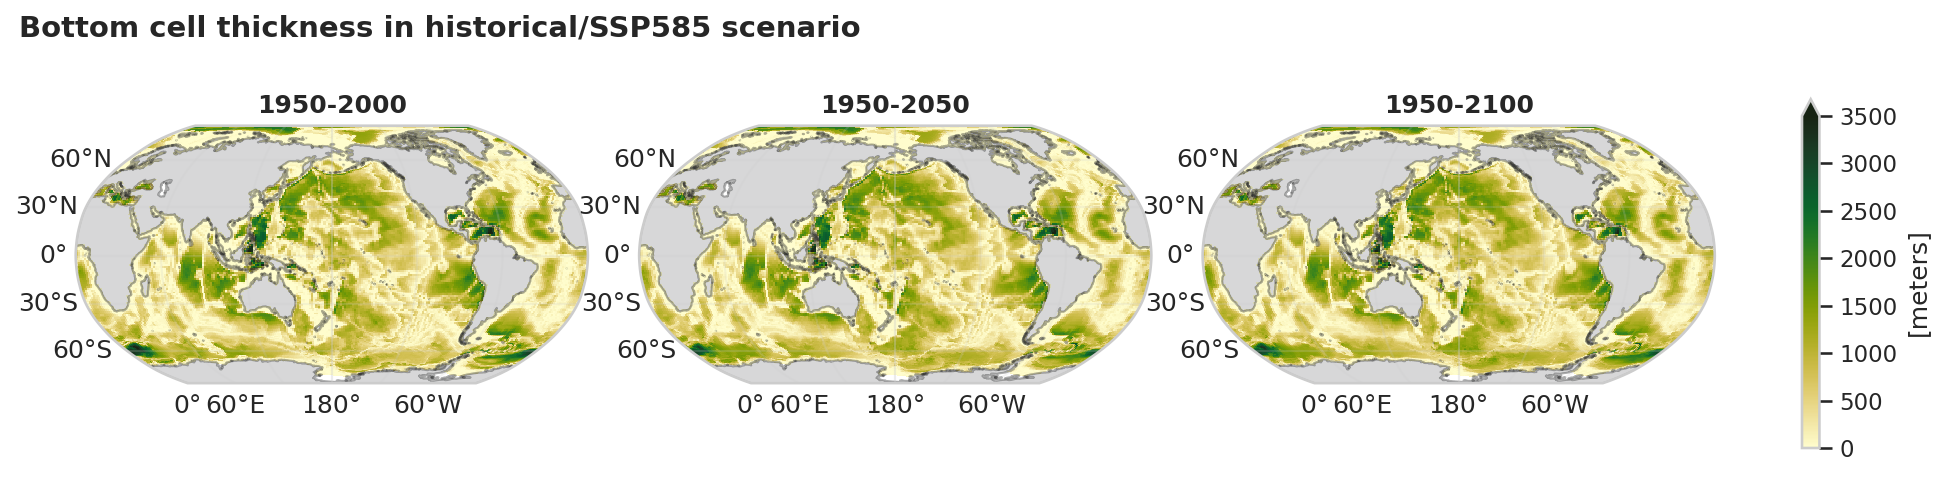

In [15]:
time_slices = [("1950", "2000"), ("1950", "2050"),  ("1950", "2100")]
expts = ["control", "forced"]
variable = "thkcello";
vmin = 0; vmax = 3500.; 
extend = "both"
# cmap = 
fig, ax = plt.subplots(1, 3, figsize = (15, 10), subplot_kw={'projection':ccrs.Robinson(central_longitude = 180)})

for (j, a) in enumerate(ax):
    cmap = "bwr"
    t0, t1 = time_slices[j]

    avg_age = average_period(ds_bottom[variable], slice(t0, t1))
        
    avg_age = avg_age.sel(exp = "forced")
    
    cb = plot_spatial(a, avg_age, vmin=vmin, vmax=vmax, extend=extend, cmap = cmo.speed)
    a.set_title(f"\n{t0}-{t1}", fontweight = "bold")

for a in ax: 
    a.coastlines(resolution = "50m", alpha = 0.2)
    a.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="#3A3B3C", alpha = 0.2))
    gl = a.gridlines(draw_labels = True, alpha = 0.2); 
    gl.top_labels = False; 

fig.subplots_adjust(wspace = 0.1)
fig.colorbar(cb, ax = ax, orientation = "vertical", fraction = 0.01, pad = 0.05, extend = "max",
            label = "[meters]")
fig.text(0.1, 0.64, 'Bottom cell thickness in historical/SSP585 scenario',
         ha='left', fontsize=14, fontweight='bold')